In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [11]:
df = pd.read_csv("data/AB_NYC_2019.csv")

print("Shape:", df.shape)
df.head()

Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [13]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [14]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

last_review          10052
reviews_per_month    10052
host_name               21
name                    16
dtype: int64

In [15]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate IDs:", df["id"].duplicated().sum())

Duplicate rows: 0
Duplicate IDs: 0


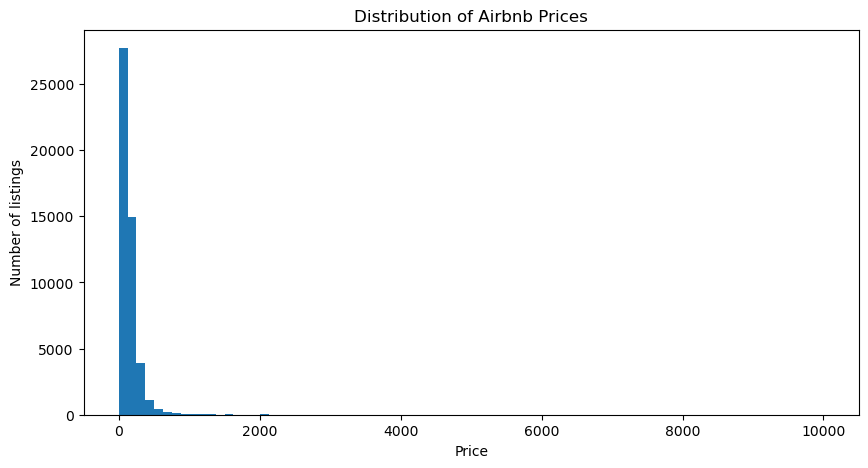

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(df["price"], bins=80)
plt.xlabel("Price")
plt.ylabel("Number of listings")
plt.title("Distribution of Airbnb Prices")
plt.show()

In [18]:
df["price"].describe()

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

In [19]:
df["price"].quantile([0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999])

0.500     106.0
0.750     175.0
0.900     269.0
0.950     355.0
0.990     799.0
0.995    1000.0
0.999    3000.0
Name: price, dtype: float64

In [20]:
data = df[df.price > 0].copy()
cutoff = data.price.quantile(.995)

In [22]:
df.groupby("room_type")["price"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

,count,mean,median
room_type,,,
Entire home/apt,25409,211.794246,160.0
Private room,22326,89.780973,70.0
Shared room,1160,70.127586,45.0


In [23]:
df.groupby("neighbourhood_group")["price"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

,count,mean,median
neighbourhood_group,,,
Manhattan,21661,196.875814,150.0
Brooklyn,20104,124.383207,90.0
Staten Island,373,114.812332,75.0
Queens,5666,99.517649,75.0
Bronx,1091,87.496792,65.0


In [24]:
data = df[df.price > 0].copy()

cutoff = data.price.quantile(.995)

data = data[data.price <= cutoff].copy()

In [25]:
features = [
    "neighbourhood_group",
    "neighbourhood",
    "latitude",
    "longitude",
    "room_type",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

X = data[features].copy()

X["has_review"] = X["reviews_per_month"].notna().astype(int)

y = data["price"]

In [26]:
cats = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

nums = [
    c for c in X.columns
    if c not in cats
]

pre = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]),
        nums
    ),
    (
        "cat",
        Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ))
        ]),
        cats
    )
])

In [27]:
train_pred = np.maximum(
    np.expm1(model.predict(X_train)),
    0
)

test_pred = np.maximum(
    np.expm1(model.predict(X_test)),
    0
)

print("Training R2:", r2_score(y_train, train_pred))
print("Testing R2 :", r2_score(y_test, test_pred))

print("Training RMSE:", mean_squared_error(y_train, train_pred) ** 0.5)
print("Testing RMSE :", mean_squared_error(y_test, test_pred) ** 0.5)

Training R2: 0.7712313087257078
Testing R2 : 0.4528903078506188
Training RMSE: 55.66420332105832
Testing RMSE : 87.37021613540564


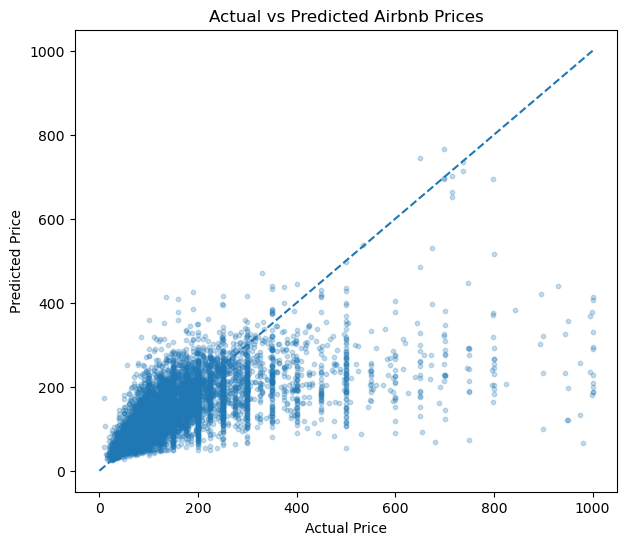

In [28]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, test_pred, alpha=0.25, s=10)

maximum = max(y_test.max(), test_pred.max())

plt.plot(
    [0, maximum],
    [0, maximum],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Airbnb Prices")
plt.show()

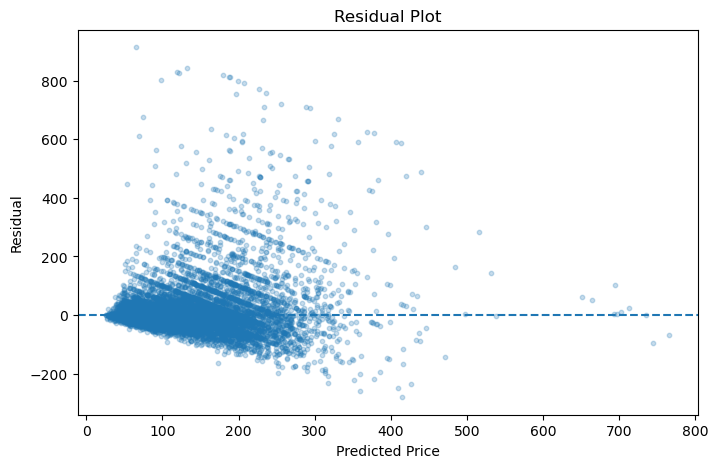

In [29]:
residuals = y_test - test_pred

plt.figure(figsize=(8, 5))

plt.scatter(test_pred, residuals, alpha=0.25, s=10)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()